In [4]:
pip install h3

In [5]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
import h3


## Dataset Filter

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
file_path = "/content/drive/MyDrive/Crimes_-_2001_to_Present_20260401.csv"

df = pd.read_csv(file_path, low_memory=False)

print(df.shape)
print(df.head())

(8522821, 22)
         ID Case Number                    Date                 Block  IUCR  \
0  14150220    JK197548  03/24/2026 12:00:00 AM   132XX S BUFFALO AVE  0920   
1  14152467    JK199655  03/24/2026 12:00:00 AM   102XX S PRAIRIE AVE  1153   
2  14146691    JK192991  03/24/2026 12:00:00 AM       004XX E ERIE ST  0486   
3  14147506    JK194051  03/24/2026 12:00:00 AM  045XX N KEYSTONE AVE  1365   
4  14145924    JK192341  03/24/2026 12:00:00 AM  020XX W WAVELAND AVE  1320   

          Primary Type                          Description  \
0  MOTOR VEHICLE THEFT                 ATTEMPT - AUTOMOBILE   
1   DECEPTIVE PRACTICE  FINANCIAL IDENTITY THEFT OVER $ 300   
2              BATTERY              DOMESTIC BATTERY SIMPLE   
3    CRIMINAL TRESPASS                         TO RESIDENCE   
4      CRIMINAL DAMAGE                           TO VEHICLE   

  Location Description  Arrest  Domestic  ...  Ward  Community Area  FBI Code  \
0               STREET   False     False  ...  10.0

## Data Cleaning

In [9]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [10]:
# Drop rows with missing Latitude/Longitude
df = df.dropna(subset=['Latitude', 'Longitude'])
print(df.shape)

(8427247, 22)


In [11]:
# Imputation for Lat/Long
# Beat, X cordinate, Y cordinate, Location


In [12]:
# 2.4 Fix Coordinate Outliers
df = df[(df['Latitude'].between(41.6, 42.1)) & (df['Longitude'].between(-88.0, -87.5))]
print(df.shape)

(8427098, 22)


In [13]:
# update the null location description with "unknown" to create a new category with unknown class
df['Location Description'] = df['Location Description'].fillna("UNKNOWN")
df[df["Location Description"] == "UNKNOWN"].shape

#print(df.shape)

(10334, 22)

In [14]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

/tmp/ipykernel_2975/3125834156.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [15]:


# Print the shape to verify how many rows remain
print("Filtered dataset shape:", df.shape)
print(df.head())

Filtered dataset shape: (8427098, 22)
         ID Case Number       Date                 Block  IUCR  \
0  14150220    JK197548 2026-03-24   132XX S BUFFALO AVE  0920   
2  14146691    JK192991 2026-03-24       004XX E ERIE ST  0486   
3  14147506    JK194051 2026-03-24  045XX N KEYSTONE AVE  1365   
4  14145924    JK192341 2026-03-24  020XX W WAVELAND AVE  1320   
6  14145789    JK192107 2026-03-24  035XX W AUGUSTA BLVD  0930   

          Primary Type                    Description Location Description  \
0  MOTOR VEHICLE THEFT           ATTEMPT - AUTOMOBILE               STREET   
2              BATTERY        DOMESTIC BATTERY SIMPLE            APARTMENT   
3    CRIMINAL TRESPASS                   TO RESIDENCE            APARTMENT   
4      CRIMINAL DAMAGE                     TO VEHICLE               STREET   
6  MOTOR VEHICLE THEFT  THEFT / RECOVERY - AUTOMOBILE               STREET   

   Arrest  Domestic  ...  Ward  Community Area  FBI Code  X Coordinate  \
0   False     False  .

In [16]:
# Drop rows where conversion failed
df = df.dropna(subset=['Date'])

In [17]:
df.tail()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
8522816,1535712,G287406,2001-01-01,100XX W OHARE ST,1140,DECEPTIVE PRACTICE,EMBEZZLEMENT,AIRPORT/AIRCRAFT,True,False,...,NaN,76.0,12,1100635.0,1934208.0,2001,01/23/2019 04:13:37 PM,41.976200,-87.905312,"(41.976200173, -87.905312411)"
8522817,1432149,G156662,2001-01-01,002XX E DELAWARE PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,False,...,NaN,NaN,26,1178492.0,1906652.0,2001,08/17/2015 03:03:40 PM,41.899161,-87.619844,"(41.899161316, -87.619843746)"
8522818,4349650,HL648777,2001-01-01,004XX W 126TH PL,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,...,9.0,53.0,06,1175398.0,1821071.0,2001,03/31/2006 10:03:38 PM,41.664388,-87.633765,"(41.664387922, -87.633765126)"
8522819,5751070,HN559680,2001-01-01,005XX W MADISON ST,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,...,42.0,28.0,06,1172495.0,1900252.0,2001,09/14/2007 01:49:03 AM,41.881734,-87.642060,"(41.881734075, -87.642059728)"
8522820,5508664,HN320275,2001-01-01,009XX N HARDING AVE,0266,CRIM SEXUAL ASSAULT,PREDATORY,RESIDENCE,False,True,...,27.0,23.0,02,1149843.0,1906023.0,2001,06/11/2007 03:52:33 PM,41.898041,-87.725087,"(41.898040875, -87.725087394)"


In [18]:
# Year as int
df['Year'] = df['Year'].astype('Int64')  # nullable int

In [19]:
# Boolean conversion
df['Arrest'] = df['Arrest'].astype('bool')
df['Domestic'] = df['Domestic'].astype('bool')

In [20]:
# Category conversion
cat_cols = ['District', 'Beat', 'Ward']
for col in cat_cols:
  df[col] = df[col].astype('category')

In [21]:
# ensure consistent ordering
df = df.sort_values(by='Date')
df = df.drop_duplicates(subset=['Case Number'], keep='first')

In [22]:
# Flag year mismatch
df['year_mismatch'] = df['Date'].dt.year != df['Year']
df['year_mismatch'].value_counts()

,count
year_mismatch,
False,8426487


In [23]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', 'year_mismatch'],
      dtype='object')

In [24]:
crime_per_beat  = df.groupby("Beat")["ID"].count()
print("Max crimes in a beat:", crime_per_beat.max(), crime_per_beat.idxmax())
print("Min crimes in a beat:", crime_per_beat.min(), crime_per_beat.idxmin())

Max crimes in a beat: 65605 421
Min crimes in a beat: 1 310


/tmp/ipykernel_2975/508562276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crime_per_beat  = df.groupby("Beat")["ID"].count()


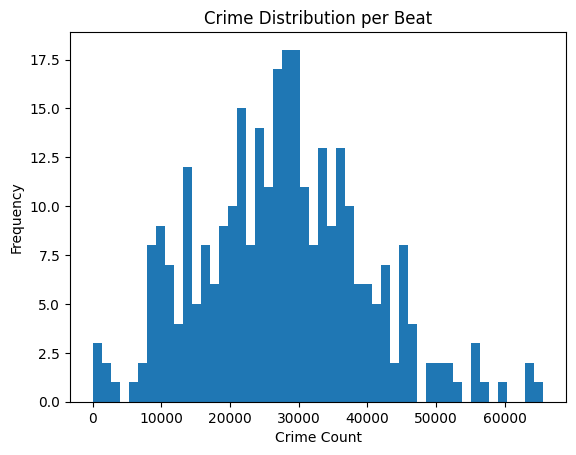

In [25]:
crime_per_beat.plot(kind='hist', bins=50, title="Crime Distribution per Beat")
plt.xlabel("Crime Count")
plt.show()

In [26]:
df = df[(df["Year"] >= 2018) & (df["Year"] <= 2025) ]

In [27]:
crime_per_year  = df.groupby("Year")["ID"].count()
print("Max crimes in a Year:", crime_per_year.max(), crime_per_year.idxmax())
print("Min crimes in a Year:", crime_per_year.min(), crime_per_year.idxmin())

Max crimes in a Year: 263498 2018
Min crimes in a Year: 202836 2021


In [28]:
# Monthly crimes
# locality area crime rate
# check the null values in entire data

In [29]:
df["Primary Type"].unique()

array(['OFFENSE INVOLVING CHILDREN', 'DECEPTIVE PRACTICE', 'SEX OFFENSE',
       'OTHER OFFENSE', 'MOTOR VEHICLE THEFT', 'CRIM SEXUAL ASSAULT',
       'CRIMINAL DAMAGE', 'CRIMINAL SEXUAL ASSAULT', 'THEFT', 'BATTERY',
       'ASSAULT', 'BURGLARY', 'WEAPONS VIOLATION', 'CRIMINAL TRESPASS',
       'NARCOTICS', 'ROBBERY', 'LIQUOR LAW VIOLATION', 'HOMICIDE',
       'PUBLIC PEACE VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER',
       'STALKING', 'INTIMIDATION', 'ARSON', 'HUMAN TRAFFICKING',
       'GAMBLING', 'KIDNAPPING', 'PROSTITUTION', 'OBSCENITY',
       'CONCEALED CARRY LICENSE VIOLATION', 'NON-CRIMINAL',
       'PUBLIC INDECENCY', 'OTHER NARCOTIC VIOLATION', 'RITUALISM'],
      dtype=object)

In [30]:
crime_per_primary_type  = df.groupby("Primary Type")["ID"].count()
print("Max crimes in Primary Type:", crime_per_primary_type.max(), crime_per_primary_type.idxmax())
print("Min crimes in a Primary Type:", crime_per_primary_type.min(), crime_per_primary_type.idxmin())

Max crimes in Primary Type: 431163 THEFT
Min crimes in a Primary Type: 1 RITUALISM


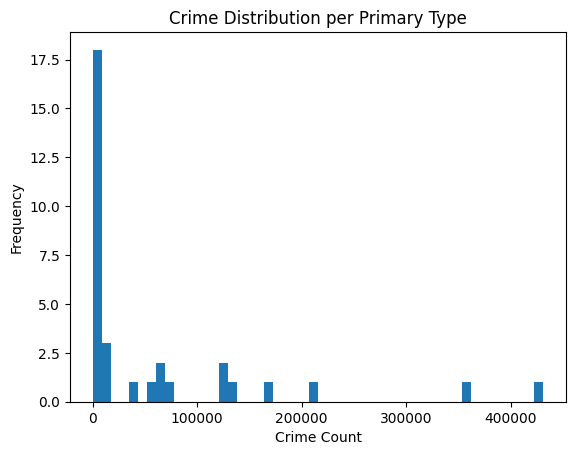

In [31]:
crime_per_primary_type.plot(kind='hist', bins=50, title="Crime Distribution per Primary Type")
plt.xlabel("Crime Count")
plt.show()

##Data Preprocessing

In [32]:
# ── Split Years ───────────────────────────────────────────────────
TRAIN_END_YEAR    = 2022
VAL_YEAR          = 2023

In [33]:
train_df = df[df['Year'] <= TRAIN_END_YEAR].copy()
val_df   = df[df['Year'] == VAL_YEAR].copy()
test_df  = df[df['Year'] >  VAL_YEAR].copy()

In [34]:
# Season mapping
MONTH_TO_SEASON = {
    12:'WINTER', 1:'WINTER',  2:'WINTER',
     3:'SPRING', 4:'SPRING',  5:'SPRING',
     6:'SUMMER', 7:'SUMMER',  8:'SUMMER',
     9:'FALL',  10:'FALL',   11:'FALL'
}

# Time-of-day bucket
def time_of_day(hour):
    if   hour < 6:  return 'NIGHT'
    elif hour < 12: return 'MORNING'
    elif hour < 18: return 'AFTERNOON'
    else:           return 'EVENING'
for name, frame in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
    frame['Date'] = pd.to_datetime(frame['Date'])
    frame.dropna(subset=['Date'], inplace=True)

    frame['year']         = frame['Date'].dt.year
    frame['month']        = frame['Date'].dt.month
    frame['day']          = frame['Date'].dt.day
    frame['hour']         = frame['Date'].dt.hour
    frame['day_of_week']  = frame['Date'].dt.dayofweek
    frame['quarter']      = frame['Date'].dt.quarter
    frame['week_of_year'] = frame['Date'].dt.isocalendar().week.astype(int)
    frame['season']       = frame['month'].map(MONTH_TO_SEASON)
    frame['is_weekend']   = frame['day_of_week'].isin([5, 6]).astype(int)
    frame['time_of_day']  = frame['hour'].apply(time_of_day)
    frame['year_month']   = frame['Date'].dt.to_period('M').astype(str)
    frame['month_index']  = (frame['year'] - frame['year'].min()) * 12 + frame['month']

In [35]:
test_df.head(8)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,day,hour,day_of_week,quarter,week_of_year,season,is_weekend,time_of_day,year_month,month_index
542074,13325994,JH101383,2024-01-01,036XX S WOLCOTT AVE,0820,THEFT,$500 AND UNDER,STREET,False,False,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542075,13368833,JH152568,2024-01-01,058XX S DR MARTIN LUTHER KING JR DR,1540,OBSCENITY,OBSCENE MATTER,APARTMENT,False,True,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542076,13356754,JH138221,2024-01-01,054XX W KAMERLING AVE,2820,OTHER OFFENSE,TELEPHONE THREAT,RESIDENCE,False,True,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542077,13325509,JH100882,2024-01-01,082XX S ELIZABETH ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,RESIDENCE,False,False,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542078,13397307,JH186496,2024-01-01,059XX N WASHTENAW AVE,0460,BATTERY,SIMPLE,APARTMENT,False,True,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542079,13484332,JH292933,2024-01-01,054XX N ARTESIAN AVE,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542080,13325219,JH100510,2024-01-01,059XX W LAKE ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,True,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1
542081,13326256,JH101535,2024-01-01,066XX S MARQUETTE RD,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,1,0,0,1,1,WINTER,0,NIGHT,2024-01,1


In [36]:
# ── H3 hex grid resolutions ───────────────────────────────────────
H3_RES_FINE      = 8    # ~460m  cells — used for predictions
H3_RES_COARSE    = 6    # ~1.2km cells — used for district summaries

print(f'Assigning H3 hex IDs (resolution {H3_RES_FINE} fine, {H3_RES_COARSE} coarse) ...')
for name, frame in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
  frame['hex_id_fine']   = frame.apply(
    lambda r: h3.latlng_to_cell(r['Latitude'], r['Longitude'], H3_RES_FINE),
    axis=1
      )
  frame['hex_id_coarse'] = frame.apply(
    lambda r: h3.latlng_to_cell(r['Latitude'], r['Longitude'], H3_RES_COARSE),
      axis=1
      )
  print(f'H3 hex IDs assigned')
  print(f'   Unique fine   cells (res={H3_RES_FINE}) : {frame["hex_id_fine"].nunique():,}')
  print(f'   Unique coarse cells (res={H3_RES_COARSE}) : {frame["hex_id_coarse"].nunique():,}')

Assigning H3 hex IDs (resolution 8 fine, 6 coarse) ...
H3 hex IDs assigned
   Unique fine   cells (res=8) : 883
   Unique coarse cells (res=6) : 32
H3 hex IDs assigned
   Unique fine   cells (res=8) : 865
   Unique coarse cells (res=6) : 32
H3 hex IDs assigned
   Unique fine   cells (res=8) : 869
   Unique coarse cells (res=6) : 31


In [37]:
train_df.tail(8)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,day_of_week,quarter,week_of_year,season,is_weekend,time_of_day,year_month,month_index,hex_id_fine,hex_id_coarse
805490,13166715,JG372117,2022-12-31 23:45:00,021XX W 50TH PL,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,True,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664cd5dfffff,862664cd7ffffff
805489,12938714,JG100579,2022-12-31 23:45:00,050XX W MONROE ST,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664c815fffff,862664c87ffffff
805488,12938578,JG100071,2022-12-31 23:45:00,001XX E RANDOLPH ST,0460,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664c1e3fffff,862664c1fffffff
805487,12938351,JG100087,2022-12-31 23:47:00,091XX S LAFLIN ST,0560,ASSAULT,SIMPLE,STREET,True,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664cd83fffff,862664cdfffffff
805486,12938340,JG100005,2022-12-31 23:47:00,091XX S LAFLIN ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,APARTMENT,True,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664cd83fffff,862664cdfffffff
805485,12938426,JG100085,2022-12-31 23:50:00,055XX W WASHINGTON BLVD,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664c839fffff,862664c87ffffff
805484,12938337,JG100016,2022-12-31 23:50:00,014XX W LUNT AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,ALLEY,False,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664d8cdfffff,862664d8fffffff
805483,13024128,JG202134,2022-12-31 23:55:00,055XX W ADAMS ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,RESIDENCE - YARD (FRONT / BACK),False,False,...,5,4,52,WINTER,1,EVENING,2022-12,60,882664c839fffff,862664c87ffffff


In [38]:
crime_per_fine  = train_df.groupby("hex_id_fine")["ID"].count()
print("Max crimes in a hex_id Fine:", crime_per_fine.max(), crime_per_fine.idxmax())
print("Min crimes in a hex_id Fine:", crime_per_fine.min(), crime_per_fine.idxmin())

Max crimes in a hex_id Fine: 18110 882664c1a9fffff
Min crimes in a hex_id Fine: 1 882664196dfffff


In [39]:
crime_per_coarse  = train_df.groupby("hex_id_coarse")["ID"].count()
print("Max crimes in a hex_id Coarse:", crime_per_coarse.max(), crime_per_coarse.idxmax())
print("Min crimes in a hex_id Coarse:", crime_per_coarse.min(), crime_per_coarse.idxmin())

Max crimes in a hex_id Coarse: 124608 862664cafffffff
Min crimes in a hex_id Coarse: 1 862664d97ffffff


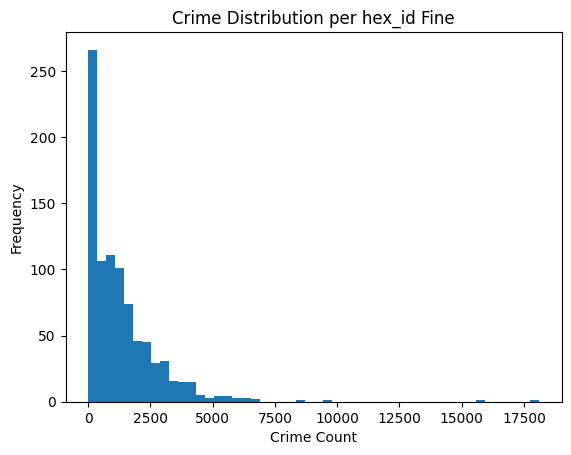

In [40]:
crime_per_fine.plot(kind='hist', bins=50, title="Crime Distribution per hex_id Fine")
plt.xlabel("Crime Count")
plt.show()

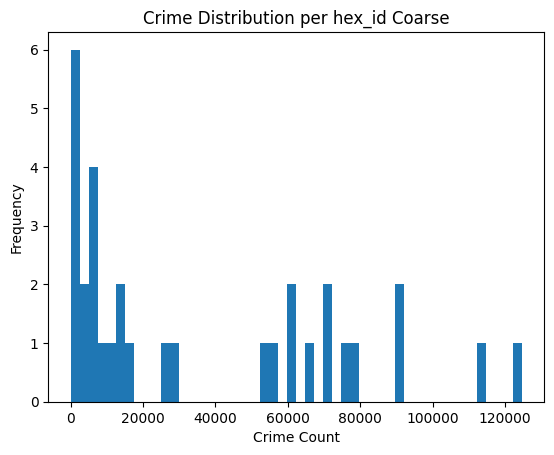

In [41]:
crime_per_coarse.plot(kind='hist', bins=50, title="Crime Distribution per hex_id Coarse")
plt.xlabel("Crime Count")
plt.show()

In [42]:
train_df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', 'year_mismatch', 'year', 'month', 'day', 'hour',
       'day_of_week', 'quarter', 'week_of_year', 'season', 'is_weekend',
       'time_of_day', 'year_month', 'month_index', 'hex_id_fine',
       'hex_id_coarse'],
      dtype='object')

In [43]:
MACRO_CATEGORY_MAP = {
    # VIOLENT
    'HOMICIDE'                 : 'VIOLENT',
    'ASSAULT'                  : 'VIOLENT',
    'BATTERY'                  : 'VIOLENT',
    'ROBBERY'                  : 'VIOLENT',
    'CRIMINAL SEXUAL ASSAULT'  : 'VIOLENT',
    'KIDNAPPING'               : 'VIOLENT',
    'HUMAN TRAFFICKING'        : 'VIOLENT',
    'INTIMIDATION'             : 'VIOLENT',
    'STALKING'                 : 'VIOLENT',
    # PROPERTY
    'THEFT'                    : 'PROPERTY',
    'BURGLARY'                 : 'PROPERTY',
    'MOTOR VEHICLE THEFT'      : 'PROPERTY',
    'ARSON'                    : 'PROPERTY',
    'CRIMINAL DAMAGE'          : 'PROPERTY',
    'CRIMINAL TRESPASS'        : 'PROPERTY',
    # DRUG
    'NARCOTICS'                : 'DRUG',
    # PUBLIC ORDER
    'PROSTITUTION'             : 'PUBLIC ORDER',
    'LIQUOR LAW VIOLATION'     : 'PUBLIC ORDER',
    'GAMBLING'                 : 'PUBLIC ORDER',
    'PUBLIC PEACE VIOLATION'   : 'PUBLIC ORDER',
    # WEAPONS
    'WEAPONS VIOLATION'        : 'WEAPONS',
}
for i in [train_df, val_df, test_df]:
  # Make sure date is datetime
  i['Primary Type']       = i['Primary Type'].astype(str).str.strip().str.upper()
  i['macro_category']     = i['Primary Type'].map(MACRO_CATEGORY_MAP).fillna('OTHER')

  # Integer encoding for ML models
  i['primary_type_enc']   = i['Primary Type'].astype('category').cat.codes
  i['macro_category_enc'] = i['macro_category'].astype('category').cat.codes

  print(f'Crime type encoding done on')
  print(f'\nMacro category distribution:')
  print(i['macro_category'].value_counts())

Crime type encoding done on

Macro category distribution:
macro_category
PROPERTY        522048
VIOLENT         375175
OTHER           181088
DRUG             43188
WEAPONS          37852
PUBLIC ORDER      8905
Name: count, dtype: int64
Crime type encoding done on

Macro category distribution:
macro_category
PROPERTY        129044
VIOLENT          80794
OTHER            36304
WEAPONS           8594
DRUG              5219
PUBLIC ORDER      1268
Name: count, dtype: int64
Crime type encoding done on

Macro category distribution:
macro_category
PROPERTY        237815
VIOLENT         153969
OTHER            72281
DRUG             13357
WEAPONS          13256
PUBLIC ORDER      2947
Name: count, dtype: int64


In [44]:
print('Aggregating to hex × year_month ...')

agg_dict = {}

for name, raw in [('train', train_df), ('val', val_df), ('test', test_df)]:
    agg = (
        raw.groupby(['hex_id_fine', 'year_month', 'year', 'month'], observed=True)
        .agg(
            total_crimes    = ('Primary Type',   'count'),
            arrest_rate     = ('Arrest',         'mean'),
            domestic_rate   = ('Domestic',       'mean'),
            top_crime_type  = ('Primary Type',   lambda x: x.mode()[0]),
            violent_crimes  = ('macro_category', lambda x: (x == 'VIOLENT').sum()),
            property_crimes = ('macro_category', lambda x: (x == 'PROPERTY').sum()),
            drug_crimes     = ('macro_category', lambda x: (x == 'DRUG').sum()),
        )
        .reset_index()
    )

    agg['month_index'] = (agg['year'] - agg['year'].min()) * 12 + agg['month']

    agg_dict[name] = agg
    print(f'  [{name}] Aggregation done')
    print(f'    Shape             : {agg.shape[0]:,} rows × {agg.shape[1]} columns')
    print(f'    Unique hex cells  : {agg["hex_id_fine"].nunique():,}')
    print(f'    Unique year_months: {agg["year_month"].nunique():,}')

train_agg_df = agg_dict['train']
val_agg_df   = agg_dict['val']
test_agg_df  = agg_dict['test']

Aggregating to hex × year_month ...
  [train] Aggregation done
    Shape             : 46,386 rows × 12 columns
    Unique hex cells  : 883
    Unique year_months: 60
  [val] Aggregation done
    Shape             : 9,421 rows × 12 columns
    Unique hex cells  : 865
    Unique year_months: 12
  [test] Aggregation done
    Shape             : 18,737 rows × 12 columns
    Unique hex cells  : 869
    Unique year_months: 24


In [45]:
train_agg_df

,hex_id_fine,year_month,year,month,total_crimes,arrest_rate,domestic_rate,top_crime_type,violent_crimes,property_crimes,drug_crimes,month_index
0,8826641903fffff,2018-04,2018,4,2,0.0,0.500,BATTERY,1,1,0,4
1,8826641903fffff,2018-05,2018,5,1,0.0,0.000,THEFT,0,1,0,5
2,8826641903fffff,2018-11,2018,11,1,0.0,0.000,CRIMINAL DAMAGE,0,1,0,11
3,8826641903fffff,2019-03,2019,3,1,0.0,0.000,DECEPTIVE PRACTICE,0,0,0,15
4,8826641903fffff,2019-05,2019,5,2,0.0,0.000,THEFT,0,2,0,17
...,...,...,...,...,...,...,...,...,...,...,...,...
46381,88275936ddfffff,2022-08,2022,8,5,0.0,0.400,OFFENSE INVOLVING CHILDREN,0,3,0,56
46382,88275936ddfffff,2022-09,2022,9,2,0.0,0.000,CRIMINAL DAMAGE,0,1,0,57
46383,88275936ddfffff,2022-10,2022,10,8,0.0,0.125,THEFT,2,4,0,58
46384,88275936ddfffff,2022-11,2022,11,5,0.4,0.000,DECEPTIVE PRACTICE,1,2,0,59


In [46]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb

from prophet import Prophet #automated model built by Meta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [47]:
LGBM_MODEL_PATH   = 'lgbm_model.pkl'

FORECAST_PATH     = 'predictions_2026.parquet'

# ── Split Years ───────────────────────────────────────────────────
TRAIN_END_YEAR    = 2022
VAL_YEAR          = 2023
# Test  → 2024 - 2025
# Future→ 2026  (prediction target)

# ── LightGBM Hyperparameters ──────────────────────────────────────
LGBM_PARAMS = {
    'objective'        : 'regression',
    'metric'           : 'mae',
    'num_leaves'       : 64,
    'learning_rate'    : 0.05,
    'max_depth'        : 8,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'n_estimators'     : 1000,
    'random_state'     : 42,
    'verbose'          : -1,
}

# ── Forecast Settings ─────────────────────────────────────────────
FORECAST_START_YEAR = 2026

# ── Ensemble Weights ──────────────────────────────────────────────
LGBM_WEIGHT    = 0.6
PROPHET_WEIGHT = 0.4


print('Configuration set')
print(f'   Train :   2020 – 2023')
print(f'   Val   :   {VAL_YEAR}')
print(f'   Test  :   {VAL_YEAR + 1} - {FORECAST_START_YEAR - 1}')
print(f'   Forecast: {FORECAST_START_YEAR}')

Configuration set
   Train :   2020 – 2023
   Val   :   2023
   Test  :   2024 - 2025
   Forecast: 2026


In [48]:
print('Adding temporal lag features ...')

# Sort by hex cell and time



for i in [train_agg_df, val_agg_df, test_agg_df]:
  i.sort_values(['hex_id_fine', 'month_index'], inplace=True)
  grp = i.groupby('hex_id_fine', observed=True)['total_crimes']

  i['lag_1month']     = grp.shift(1)
  i['lag_3month']     = grp.shift(3)
  i['lag_12month']    = grp.shift(12)
  i['rolling_3m_avg'] = grp.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
  i['rolling_6m_avg'] = grp.transform(lambda x: x.shift(1).rolling(6,  min_periods=1).mean())

  # Year-over-year growth %
  i['yoy_growth'] = (
      (i['total_crimes'] - i['lag_12month']) /
      i['lag_12month'].replace(0, np.nan)
  ) * 100

  # Fill NaNs from shifting (early months have no history)
  lag_cols = ['lag_1month','lag_3month','lag_12month',
            'rolling_3m_avg','rolling_6m_avg','yoy_growth']
  i[lag_cols] = i[lag_cols].fillna(0)

  print('Temporal lag features added:')
  print('lag_1month, lag_3month, lag_12month,')
  print('rolling_3m_avg, rolling_6m_avg, yoy_growth')
  i[['hex_id_fine','year_month','total_crimes',
      'lag_1month','lag_12month','rolling_3m_avg','yoy_growth']].tail(8)

Adding temporal lag features ...
Temporal lag features added:
lag_1month, lag_3month, lag_12month,
rolling_3m_avg, rolling_6m_avg, yoy_growth
Temporal lag features added:
lag_1month, lag_3month, lag_12month,
rolling_3m_avg, rolling_6m_avg, yoy_growth
Temporal lag features added:
lag_1month, lag_3month, lag_12month,
rolling_3m_avg, rolling_6m_avg, yoy_growth


In [49]:
train_agg_df.tail(8)

,hex_id_fine,year_month,year,month,total_crimes,arrest_rate,domestic_rate,top_crime_type,violent_crimes,property_crimes,drug_crimes,month_index,lag_1month,lag_3month,lag_12month,rolling_3m_avg,rolling_6m_avg,yoy_growth
46378,88275936ddfffff,2022-05,2022,5,3,0.0000,0.0000,CRIMINAL DAMAGE,0,2,0,53,7.0000,6.0000,4.0000,4.6667,4.0000,-25.0000
46379,88275936ddfffff,2022-06,2022,6,5,0.2000,0.0000,THEFT,1,3,0,54,3.0000,1.0000,3.0000,3.6667,4.1667,66.6667
46380,88275936ddfffff,2022-07,2022,7,5,0.0000,0.8000,OFFENSE INVOLVING CHILDREN,1,0,0,55,5.0000,7.0000,1.0000,5.0000,4.5000,400.0000
46381,88275936ddfffff,2022-08,2022,8,5,0.0000,0.4000,OFFENSE INVOLVING CHILDREN,0,3,0,56,5.0000,3.0000,6.0000,4.3333,4.5000,-16.6667
46382,88275936ddfffff,2022-09,2022,9,2,0.0000,0.0000,CRIMINAL DAMAGE,0,1,0,57,5.0000,5.0000,4.0000,5.0000,4.3333,-50.0000
46383,88275936ddfffff,2022-10,2022,10,8,0.0000,0.1250,THEFT,2,4,0,58,2.0000,5.0000,6.0000,4.0000,4.5000,33.3333
46384,88275936ddfffff,2022-11,2022,11,5,0.4000,0.0000,DECEPTIVE PRACTICE,1,2,0,59,8.0000,5.0000,2.0000,5.0000,4.6667,150.0000
46385,88275936ddfffff,2022-12,2022,12,1,0.0000,0.0000,DECEPTIVE PRACTICE,0,0,0,60,5.0000,2.0000,3.0000,5.0000,5.0000,-66.6667


In [50]:

print('Adding spatial lag features (neighbor hex crime counts) ...')
print('This may take a few minutes for large datasets ...')

# Pre-build lookup: {(hex_id, year_month) → total_crimes}
for i in [train_agg_df, val_agg_df, test_agg_df]:
  crime_lookup = i.set_index(['hex_id_fine', 'year_month'])['total_crimes'].to_dict()

  neighbor_avg = []
  neighbor_max = []

  for _, row in i.iterrows():
      neighbors       = set(h3.grid_disk(row['hex_id_fine'], 1)) - {row['hex_id_fine']}
      neighbor_counts = [crime_lookup.get((n, row['year_month']), 0) for n in neighbors]
      neighbor_avg.append(np.mean(neighbor_counts) if neighbor_counts else 0.0)
      neighbor_max.append(np.max(neighbor_counts)  if neighbor_counts else 0.0)

  i['neighbor_avg_crime'] = neighbor_avg
  i['neighbor_max_crime'] = neighbor_max
  print('Spatial lag features added: neighbor_avg_crime, neighbor_max_crime')



Adding spatial lag features (neighbor hex crime counts) ...
This may take a few minutes for large datasets ...
Spatial lag features added: neighbor_avg_crime, neighbor_max_crime
Spatial lag features added: neighbor_avg_crime, neighbor_max_crime
Spatial lag features added: neighbor_avg_crime, neighbor_max_crime


In [51]:
train_agg_df.tail(10)

,hex_id_fine,year_month,year,month,total_crimes,arrest_rate,domestic_rate,top_crime_type,violent_crimes,property_crimes,drug_crimes,month_index,lag_1month,lag_3month,lag_12month,rolling_3m_avg,rolling_6m_avg,yoy_growth,neighbor_avg_crime,neighbor_max_crime
46376,88275936ddfffff,2022-03,2022,3,1,0.0000,0.0000,THEFT,0,1,0,51,6.0000,3.0000,6.0000,4.6667,4.3333,-83.3333,2.8333,8
46377,88275936ddfffff,2022-04,2022,4,7,0.0000,0.4286,BURGLARY,2,4,0,52,1.0000,5.0000,3.0000,4.0000,3.8333,133.3333,1.1667,3
46378,88275936ddfffff,2022-05,2022,5,3,0.0000,0.0000,CRIMINAL DAMAGE,0,2,0,53,7.0000,6.0000,4.0000,4.6667,4.0000,-25.0000,1.8333,6
46379,88275936ddfffff,2022-06,2022,6,5,0.2000,0.0000,THEFT,1,3,0,54,3.0000,1.0000,3.0000,3.6667,4.1667,66.6667,2.3333,11
46380,88275936ddfffff,2022-07,2022,7,5,0.0000,0.8000,OFFENSE INVOLVING CHILDREN,1,0,0,55,5.0000,7.0000,1.0000,5.0000,4.5000,400.0000,2.3333,7
46381,88275936ddfffff,2022-08,2022,8,5,0.0000,0.4000,OFFENSE INVOLVING CHILDREN,0,3,0,56,5.0000,3.0000,6.0000,4.3333,4.5000,-16.6667,2.8333,10
46382,88275936ddfffff,2022-09,2022,9,2,0.0000,0.0000,CRIMINAL DAMAGE,0,1,0,57,5.0000,5.0000,4.0000,5.0000,4.3333,-50.0000,1.8333,6
46383,88275936ddfffff,2022-10,2022,10,8,0.0000,0.1250,THEFT,2,4,0,58,2.0000,5.0000,6.0000,4.0000,4.5000,33.3333,3.1667,12
46384,88275936ddfffff,2022-11,2022,11,5,0.4000,0.0000,DECEPTIVE PRACTICE,1,2,0,59,8.0000,5.0000,2.0000,5.0000,4.6667,150.0000,3.0000,11
46385,88275936ddfffff,2022-12,2022,12,1,0.0000,0.0000,DECEPTIVE PRACTICE,0,0,0,60,5.0000,2.0000,3.0000,5.0000,5.0000,-66.6667,2.5000,9


In [52]:
print('Adding risk tier labels ...')

# Compute percentile thresholds ONCE from training data only
pct = (
    train_agg_df.groupby('year_month')['total_crimes']
    .quantile([0.25, 0.75, 0.90])
    .unstack(level=1)
    .rename(columns={0.25: 'p25', 0.75: 'p75', 0.90: 'p90'})
)

def assign_tier(row):
    if   row['total_crimes'] <= row['p25']: return 'LOW'
    elif row['total_crimes'] <= row['p75']: return 'MEDIUM'
    elif row['total_crimes'] <= row['p90']: return 'HIGH'
    else:                                   return 'CRITICAL'

for name, df in [('train', train_agg_df), ('val', val_agg_df), ('test', test_agg_df)]:
    # Merge using train-derived thresholds; val/test months not in pct get NaN → fillna
    merged = df.merge(pct, on='year_month', how='left')

    # For val/test months unseen in train, fall back to overall train percentiles
    overall = train_agg_df['total_crimes'].quantile([0.25, 0.75, 0.90])
    merged['p25'] = merged['p25'].fillna(overall[0.25])
    merged['p75'] = merged['p75'].fillna(overall[0.75])
    merged['p90'] = merged['p90'].fillna(overall[0.90])

    merged['risk_tier'] = merged.apply(assign_tier, axis=1)
    merged.drop(columns=['p25', 'p75', 'p90'], inplace=True)

    # Write back to the actual dataframe
    if name == 'train': train_agg_df = merged
    elif name == 'val': val_agg_df   = merged
    else:               test_agg_df  = merged

    print(f'\n[{name}] Risk tiers assigned')
    print(merged['risk_tier'].value_counts())
    print((merged['risk_tier'].value_counts(normalize=True) * 100).round(1))

Adding risk tier labels ...

[train] Risk tiers assigned
risk_tier
MEDIUM      22791
LOW         12246
HIGH         6785
CRITICAL     4564
Name: count, dtype: int64
risk_tier
MEDIUM     49.1000
LOW        26.4000
HIGH       14.6000
CRITICAL    9.8000
Name: proportion, dtype: float64

[val] Risk tiers assigned
risk_tier
MEDIUM      4512
LOW         2146
HIGH        1623
CRITICAL    1140
Name: count, dtype: int64
risk_tier
MEDIUM     47.9000
LOW        22.8000
HIGH       17.2000
CRITICAL   12.1000
Name: proportion, dtype: float64

[test] Risk tiers assigned
risk_tier
MEDIUM      9378
LOW         4339
HIGH        3046
CRITICAL    1974
Name: count, dtype: int64
risk_tier
MEDIUM     50.1000
LOW        23.2000
HIGH       16.3000
CRITICAL   10.5000
Name: proportion, dtype: float64


In [53]:
test_agg_df.tail(20)

,hex_id_fine,year_month,year,month,total_crimes,arrest_rate,domestic_rate,top_crime_type,violent_crimes,property_crimes,drug_crimes,month_index,lag_1month,lag_3month,lag_12month,rolling_3m_avg,rolling_6m_avg,yoy_growth,neighbor_avg_crime,neighbor_max_crime,risk_tier
18717,88275936ddfffff,2024-02,2024,2,7,0.0000,0.0000,DECEPTIVE PRACTICE,1,3,0,2,2.0000,0.0000,0.0000,2.0000,2.0000,0.0000,3.1667,7,LOW
18718,88275936ddfffff,2024-03,2024,3,6,0.1667,0.3333,BATTERY,2,1,0,3,7.0000,0.0000,0.0000,4.5000,4.5000,0.0000,2.0000,7,LOW
18719,88275936ddfffff,2024-04,2024,4,4,0.0000,0.0000,BATTERY,2,1,0,4,6.0000,2.0000,0.0000,5.0000,5.0000,0.0000,1.3333,5,LOW
18720,88275936ddfffff,2024-05,2024,5,2,0.0000,0.5000,OTHER OFFENSE,0,1,0,5,4.0000,7.0000,0.0000,5.6667,4.7500,0.0000,2.0000,4,LOW
18721,88275936ddfffff,2024-06,2024,6,2,0.0000,0.0000,DECEPTIVE PRACTICE,0,1,0,6,2.0000,6.0000,0.0000,4.0000,4.2000,0.0000,2.5000,9,LOW
18722,88275936ddfffff,2024-07,2024,7,6,0.0000,0.0000,CRIMINAL DAMAGE,0,4,0,7,2.0000,4.0000,0.0000,2.6667,3.8333,0.0000,3.0000,9,LOW
18723,88275936ddfffff,2024-08,2024,8,5,0.0000,0.0000,CRIMINAL DAMAGE,0,5,0,8,6.0000,2.0000,0.0000,3.3333,4.5000,0.0000,2.6667,6,LOW
18724,88275936ddfffff,2024-09,2024,9,6,0.0000,0.1667,CRIMINAL DAMAGE,1,5,0,9,5.0000,2.0000,0.0000,4.3333,4.1667,0.0000,2.1667,12,LOW
18725,88275936ddfffff,2024-10,2024,10,5,0.0000,0.0000,CRIMINAL DAMAGE,0,2,0,10,6.0000,6.0000,0.0000,5.6667,4.1667,0.0000,1.1667,5,LOW
18726,88275936ddfffff,2024-11,2024,11,4,0.0000,0.0000,CRIMINAL DAMAGE,1,3,0,11,5.0000,5.0000,0.0000,5.3333,4.3333,0.0000,1.3333,5,LOW


##Model Training

In [54]:
!pip install lightgbm prophet scikit-learn pandas numpy pyarrow joblib shap --quiet
print('Done')

Done


In [55]:
# Encode hex_id (high-cardinality string → integer)
le_hex = LabelEncoder()
for name, df in [('train', train_agg_df), ('val', val_agg_df), ('test', test_agg_df)]:
  i['hex_id_enc'] = le_hex.fit_transform(i['hex_id_fine'].astype(str))

# Define feature columns (use only those present in the dataframe)
ALL_FEATURE_COLS = [
    'hex_id_enc', 'year', 'month', 'quarter', 'month_index',
    'hex_id',
    'lag_1month', 'lag_3month', 'lag_12month',
    'rolling_3m_avg', 'rolling_6m_avg', 'yoy_growth',
    'neighbor_avg_crime', 'neighbor_max_crime',
    'violent_crimes', 'property_crimes', 'drug_crimes',
    'arrest_rate', 'domestic_rate',
]

TARGET_COL  = 'total_crimes'
FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c in train_agg_df.columns]

# Temporal split — NO random shuffle (prevents leakage)


X_train, y_train = train_agg_df[FEATURE_COLS], train_agg_df[TARGET_COL]
X_val,   y_val   = val_agg_df[FEATURE_COLS],   val_agg_df[TARGET_COL]
X_test,  y_test  = test_agg_df[FEATURE_COLS],  test_agg_df[TARGET_COL]

print('   Features and splits ready')
print(f'   Features     : {len(FEATURE_COLS)} → {FEATURE_COLS}')
print(f'   Train shape  : {X_train.shape}')
print(f'   Val   shape  : {X_val.shape}')
print(f'   Test  shape  : {X_test.shape}')

   Features and splits ready
   Features     : 16 → ['year', 'month', 'month_index', 'lag_1month', 'lag_3month', 'lag_12month', 'rolling_3m_avg', 'rolling_6m_avg', 'yoy_growth', 'neighbor_avg_crime', 'neighbor_max_crime', 'violent_crimes', 'property_crimes', 'drug_crimes', 'arrest_rate', 'domestic_rate']
   Train shape  : (46386, 16)
   Val   shape  : (9421, 16)
   Test  shape  : (18737, 16)


In [56]:
def evaluate(name, y_true, y_pred):
    """Print regression metrics for a model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    print(f'  {name:<25}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.1f}%')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []
print('Baseline model evaluation on VALIDATION set:')
print('-' * 70)

# ── Baseline 1: Naive (predict = last month) ─────────────────────
naive_pred = val_agg_df['lag_1month'] if 'lag_1month' in val_agg_df.columns else pd.Series(
    [y_train.mean()] * len(y_val), index=y_val.index
)
results.append(evaluate('Naive (lag_1month)', y_val, naive_pred.values))

# ── Baseline 2: Historical Mean (predict = avg of same month) ────
monthly_means = train_agg_df.groupby('month')[TARGET_COL].mean()
hist_mean_pred = val_agg_df['month'].map(monthly_means)
results.append(evaluate('Historical Mean', y_val, hist_mean_pred.values))

# ── Baseline 3: Rolling 3-month average ──────────────────────────
if 'rolling_3m_avg' in val_agg_df.columns:
    results.append(evaluate('Rolling 3M Avg', y_val, val_agg_df['rolling_3m_avg'].values))

print('-' * 70)
print('⚠️  LightGBM must beat these baselines to be useful.')

Baseline model evaluation on VALIDATION set:
----------------------------------------------------------------------
  Naive (lag_1month)         MAE=8.00  RMSE=14.12  R²=0.7392  MAPE=42.9%
  Historical Mean            MAE=18.58  RMSE=27.71  R²=-0.0041  MAPE=278.6%
  Rolling 3M Avg             MAE=7.38  RMSE=13.57  R²=0.7590  MAPE=39.9%
----------------------------------------------------------------------
⚠️  LightGBM must beat these baselines to be useful.


###LightGBM

In [57]:
print('Training LightGBM model ...')
print(f'  Params: {LGBM_PARAMS}')
print('-' * 50)
lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS)

lgbm_model.fit(
    X_train, y_train,
    eval_set              = [(X_val, y_val)],
    eval_metric           = 'mae',
    callbacks             = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ]
)

print(f'\n✅ Training complete')
print(f'   Best iteration : {lgbm_model.best_iteration_}')

Training LightGBM model ...
  Params: {'objective': 'regression', 'metric': 'mae', 'num_leaves': 64, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 1000, 'random_state': 42, 'verbose': -1}
--------------------------------------------------
[100]	valid_0's l1: 2.0298
[200]	valid_0's l1: 1.99773

✅ Training complete
   Best iteration : 194


In [58]:
# Evaluate LightGBM on val and test
lgbm_val_pred  = lgbm_model.predict(X_val)
lgbm_test_pred = lgbm_model.predict(X_test)

# Clip negatives (crime counts can't be negative)
lgbm_val_pred  = np.clip(lgbm_val_pred, 0, None)
lgbm_test_pred = np.clip(lgbm_test_pred, 0, None)

print('LightGBM evaluation:')
print('-' * 70)
results.append(evaluate('LightGBM (Validation)', y_val, lgbm_val_pred))
results.append(evaluate('LightGBM (Test)',       y_test, lgbm_test_pred))
print('-' * 70)

LightGBM evaluation:
----------------------------------------------------------------------
  LightGBM (Validation)      MAE=2.00  RMSE=3.08  R²=0.9876  MAPE=12.5%
  LightGBM (Test)            MAE=1.73  RMSE=2.69  R²=0.9903  MAPE=10.9%
----------------------------------------------------------------------


In [59]:
# neighbor features should correlate with lag_1month, not with total_crimes directly
print(train_agg_df[['total_crimes', 'lag_1month', 'neighbor_avg_crime']].corr())

                    total_crimes  lag_1month  neighbor_avg_crime
total_crimes              1.0000      0.9258              0.7396
lag_1month                0.9258      1.0000              0.7150
neighbor_avg_crime        0.7396      0.7150              1.0000


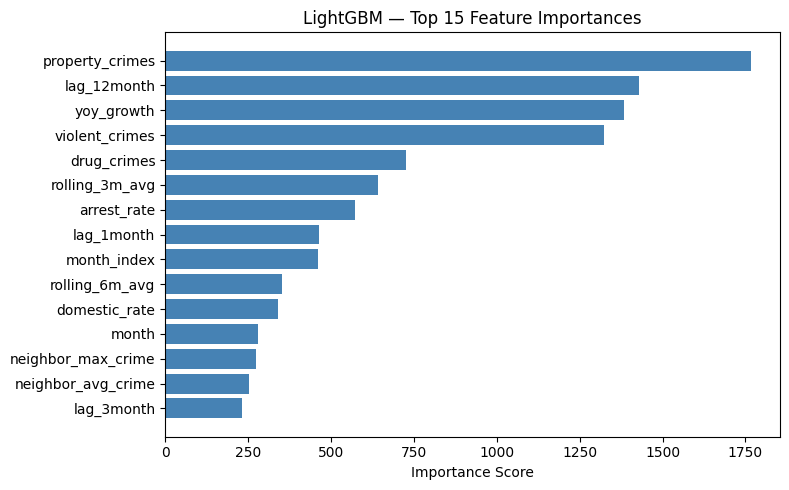

📊 Feature importance plot saved  →  lgbm_feature_importance.png


In [60]:
# ── Feature Importance Plot ───────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('LightGBM — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=120)
plt.show()
print('📊 Feature importance plot saved  →  lgbm_feature_importance.png')

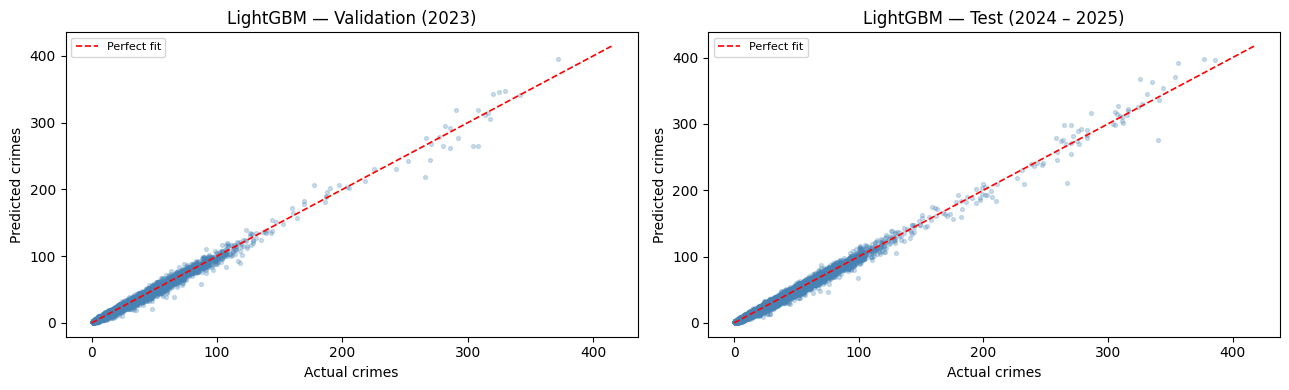

📊 Predicted vs Actual plot saved  →  lgbm_pred_vs_actual.png


In [61]:
# ── Predicted vs Actual Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  lgbm_val_pred,  f'Validation ({VAL_YEAR})'),
    (axes[1], y_test, lgbm_test_pred, f'Test ({VAL_YEAR+1} – {FORECAST_START_YEAR-1})'),
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color='steelblue')
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='Perfect fit')
    ax.set_xlabel('Actual crimes')
    ax.set_ylabel('Predicted crimes')
    ax.set_title(f'LightGBM — {title}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('lgbm_pred_vs_actual.png', dpi=120)
plt.show()
print('📊 Predicted vs Actual plot saved  →  lgbm_pred_vs_actual.png')

##